# MLDL2 Homework 3

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from torchvision import datasets
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, ConcatDataset
import torch.optim as optim

# 기본 설정
BATCH_SIZE = 32
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# 1. Load the CIFAR-10, CIFAR-100 Datasets

1. 데이터 증강(Data Augmentation)
Resize: CIFAR-10과 CIFAR-100 데이터셋의 이미지 크기를 224x224로 조정했습니다. 이 과정은 모델의 입력 크기에 맞게 이미지를 조정하여, 모델이 일관된 입력을 받을 수 있도록 합니다.
Normalization: 각 데이터셋(CIFAR-10, CIFAR-100)에 대해 고유의 평균과 표준편차를 사용하여 이미지를 정규화했습니다. 이는 모델이 빠르게 수렴할 수 있도록 도와줍니다.
2. 데이터셋 결합(Concatenation of Datasets)
CIFAR-10과 CIFAR-100의 결합: 두 데이터셋을 결합하여 모델이 다양한 패턴을 학습할 수 있도록 했습니다. CIFAR-10은 10개의 클래스를, CIFAR-100은 100개의 클래스를 포함하고 있어, 결합된 데이터셋은 모델이 더 다양한 이미지 특징을 학습하는 데 기여합니다.
3. 모델 아키텍처(Model Architecture)
SimpleCNN 모델: 간단한 CNN 모델을 정의하여, CIFAR-10/100 데이터셋에서 이미지를 효과적으로 학습할 수 있도록 했습니다. 모델은 두 개의 Conv 레이어와 두 개의 Fully Connected 레이어로 구성되어 있으며, 각 레이어는 ReLU 활성화 함수와 MaxPooling을 포함합니다.
4. 혼합 정밀도 학습(Mixed Precision Training)
torch.amp.autocast와 torch.amp.GradScaler를 사용하여 혼합 정밀도 학습을 적용했습니다. 이 기법은 FP32와 FP16(반정밀도) 연산을 결합하여 GPU 메모리 사용량을 줄이고, 학습 속도를 높이는 데 기여합니다.
5. 손실 함수 및 옵티마이저(Loss Function and Optimizer)
CrossEntropyLoss: 다중 클래스 분류 문제에서 자주 사용되는 손실 함수로, 모델의 예측이 실제 라벨과 얼마나 일치하는지를 평가합니다.
AdamW 옵티마이저: 학습 속도를 제어하고 가중치 감쇠(weight decay)를 포함하여 모델의 일반화 성능을 높입니다.
6. 학습률 스케줄러(Learning Rate Scheduler)
ReduceLROnPlateau: 손실이 일정 기간 동안 개선되지 않으면 학습률을 줄이는 스케줄러를 사용했습니다. 이 기법은 학습 속도를 동적으로 조정하여 더 나은 성능을 얻을 수 있게 해줍니다.
7. 모델 체크포인트(Model Checkpointing)
최적 모델 저장: 각 에포크의 손실을 모니터링하여, 가장 낮은 손실을 기록한 모델을 저장했습니다. 이를 통해 가장 성능이 좋은 모델을 보존할 수 있습니다.
8. 배치 크기 조정(Batch Size Adjustment)
배치 크기 32: GPU 메모리 문제를 해결하기 위해 배치 크기를 32로 조정했습니다. 이는 학습의 안정성과 효율성을 높이는 데 기여합니다.

In [3]:
# 1. CIFAR-10/100 데이터셋을 사용한 Pre-training

# CIFAR-10과 CIFAR-100 데이터셋을 위한 전처리
cifar10_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 이미지 크기를 224x224로 조정
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.447), (0.247, 0.244, 0.262))  # CIFAR-10 데이터셋의 평균과 표준편차
])

cifar100_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 이미지 크기를 224x224로 조정
    transforms.ToTensor(),
    transforms.Normalize((0.507, 0.487, 0.441), (0.267, 0.256, 0.276))  # CIFAR-100 데이터셋의 평균과 표준편차
])


In [4]:
# CIFAR-10과 CIFAR-100 데이터셋 로드
cifar10_train_dataset = datasets.CIFAR10(root="./data/", train=True, download=True, transform=cifar10_transform)
cifar100_train_dataset = datasets.CIFAR100(root="./data/", train=True, download=True, transform=cifar100_transform)

# CIFAR-10과 CIFAR-100 데이터셋 병합
cifar_train_loader = DataLoader(dataset=ConcatDataset([cifar10_train_dataset, cifar100_train_dataset]),
                                batch_size=BATCH_SIZE, shuffle=True)

Files already downloaded and verified
Files already downloaded and verified


In [29]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# 데이터셋의 라벨 확인
for _, labels in cifar_train_loader:
    print(labels.min().item(), labels.max().item())
    break


0 95


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # 각 레이어 이후의 출력 크기를 계산하여 입력 크기를 설정합니다.
        self.fc1 = nn.Linear(128 * 56 * 56, 256)  # 크기를 실제 계산된 값으로 수정
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [13]:
import os

# 모델 초기화 (CIFAR-100의 100개 클래스를 위한 모델)
model = SimpleCNN(num_classes=100).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

# 혼합 정밀도 스케일러
scaler = torch.amp.GradScaler()

# 학습 초기화
start_epoch = 0
best_loss = float('inf')
checkpoint_dir = "/content/drive/MyDrive/AI인턴십/model/"
# pretrained_model_path = os.path.join(checkpoint_dir, "pretrained_cifar_best.pth")

# 이전에 저장된 체크포인트가 있는지 확인 (처음부터 학습하므로 주석 처리)
# if os.path.exists(pretrained_model_path):
#     checkpoint = torch.load(pretrained_model_path)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
#     scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
#     scaler.load_state_dict(checkpoint['scaler_state_dict'])
#     start_epoch = checkpoint['epoch']
#     best_loss = checkpoint['loss']
#     print(f"Checkpoint loaded, resuming from epoch {start_epoch+1}, with best loss: {best_loss:.4f}")

# Pre-training 모델 학습
num_epochs = 10

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(cifar_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(cifar_train_loader)
    epoch_acc = 100 * correct / total
    scheduler.step(epoch_loss)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

    # 최적 모델 저장
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch + 1
        best_model_path = os.path.join(checkpoint_dir, f"pretrained_cifar_best_{best_epoch}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'loss': best_loss,
        }, best_model_path)
        print(f"New best model saved at epoch {best_epoch} with loss: {best_loss:.4f}")

  0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [1/10], Loss: 3.6928, Acc: 17.46%
New best model saved at epoch 1 with loss: 3.6928


  0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [2/10], Loss: 3.0204, Acc: 25.83%
New best model saved at epoch 2 with loss: 3.0204


  0%|          | 0/3125 [00:00<?, ?it/s]

...

Epoch [8/10], Loss: 1.1801, Acc: 66.83%
New best model saved at epoch 8 with loss: 1.1801


  0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [9/10], Loss: 0.9230, Acc: 73.50%
New best model saved at epoch 9 with loss: 0.9230


  0%|          | 0/3125 [00:00<?, ?it/s]

Epoch [10/10], Loss: 0.7150, Acc: 79.14%
New best model saved at epoch 10 with loss: 0.7150


# 2. Load the Caltech UCSD Birds-200 Dataset

## simplecNN(pre-training) 모델 사용

In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# SimpleCNN 모델 정의
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=200):  # 200개의 클래스를 예측
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.max_pool2d(x, 2)
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
# CUB-200-2011 데이터셋 클래스 정의
class CUB_Dataset(Dataset):
    def __init__(self, img_file, label_file, transform=None):
        self.img = np.load(img_file)
        self.labels = np.load(label_file)
        self.transform = transform

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        image = self.img[idx]
        label = self.labels[idx]

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label

# 데이터 증강 적용 (Albumentations 사용)
cub_bird_transform = A.Compose([
    A.HorizontalFlip(p=0.5),  # 수평 뒤집기
    A.RandomRotate90(p=0.5),  # 랜덤 90도 회전
    A.RandomResizedCrop(224, 224, scale=(0.8, 1.0), p=0.5),  # 랜덤 크롭 및 리사이즈
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),  # 색상 조절
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # 정규화
    ToTensorV2(),  # 텐서로 변환
])

# 검증 데이터는 증강을 하지 않음
cub_val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [9]:

# 데이터셋 로드
cub_train_dataset = CUB_Dataset(img_file="/content/drive/MyDrive/AI인턴십/CUB_train_images.npy",
                                label_file="/content/drive/MyDrive/AI인턴십/CUB_train_labels.npy", transform=cub_bird_transform)
cub_train_loader = DataLoader(cub_train_dataset, batch_size=64, shuffle=True)

cub_val_dataset = CUB_Dataset(img_file="/content/drive/MyDrive/AI인턴십/CUB_val_images.npy",
                              label_file="/content/drive/MyDrive/AI인턴십/CUB_val_labels.npy", transform=cub_val_transform)
cub_val_loader = DataLoader(cub_val_dataset, batch_size=64, shuffle=False)

In [ ]:
# Number of samples in the dataset

print("cifar10 train dataset size : ", len(cifar10_train_dataset))
print("cifar100 train dataset size : ", len(cifar100_train_dataset))
print("caltech bird train dataset size : ", len(cub_train_dataset))
print("caltech bird validation dataset size : ", len(cub_val_dataset))

cifar10 train dataset size :  50000
cifar100 train dataset size :  50000
caltech bird train dataset size :  5994
caltech bird validation dataset size :  2897


## CIFAR-10 Visualiztion

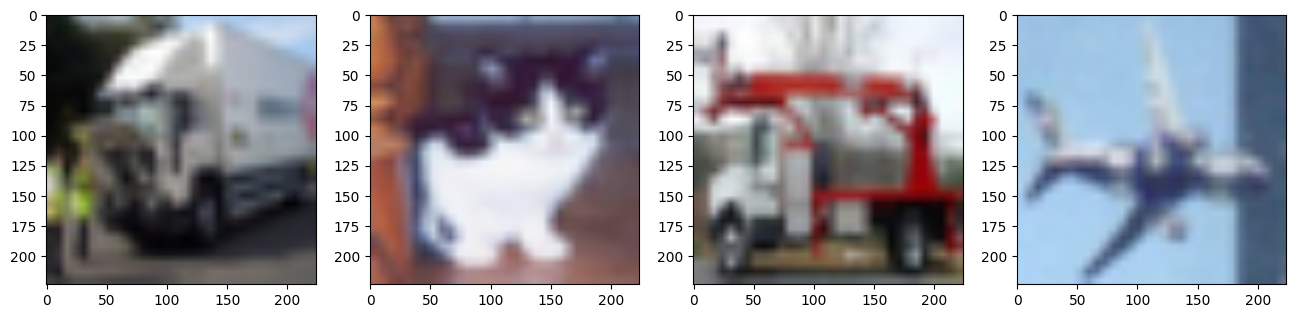

tensor([9, 3, 9, 0])


In [ ]:
# Plot the training images and labels

cifar10_denormalize = transforms.Normalize(mean=[-0.491/0.247, -0.482/0.244, -0.447/0.262], std=[1/0.247, 1/0.244, 1/0.262])
to_pil_image = transforms.functional.to_pil_image

images, labels = next(iter(cifar10_train_loader))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(to_pil_image(cifar10_denormalize(images[0])))
ax[1].imshow(to_pil_image(cifar10_denormalize(images[1])))
ax[2].imshow(to_pil_image(cifar10_denormalize(images[2])))
ax[3].imshow(to_pil_image(cifar10_denormalize(images[3])))
plt.show()

print(labels[:4])

## CIFAR-100 Visualiztion

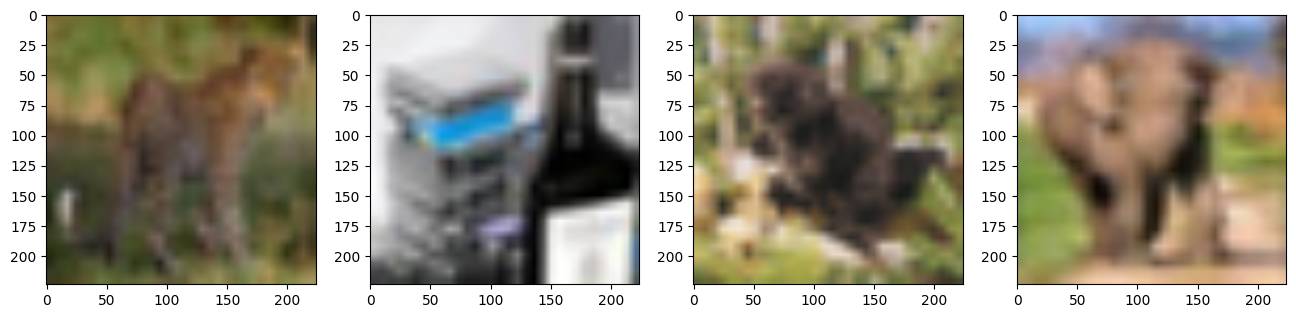

tensor([42,  9,  4, 31])


In [ ]:
# Plot the training images and labels

cifar100_denormalize = transforms.Normalize(mean=[-0.507/0.267, -0.487/0.256, -0.441/0.276], std=[1/0.267, 1/0.256, 1/0.276])
to_pil_image = transforms.functional.to_pil_image

images, labels = next(iter(cifar100_train_loader))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(to_pil_image(cifar100_denormalize(images[0])))
ax[1].imshow(to_pil_image(cifar100_denormalize(images[1])))
ax[2].imshow(to_pil_image(cifar100_denormalize(images[2])))
ax[3].imshow(to_pil_image(cifar100_denormalize(images[3])))
plt.show()

print(labels[:4])

## Caltech UCSD Birds-200 Visualiztion

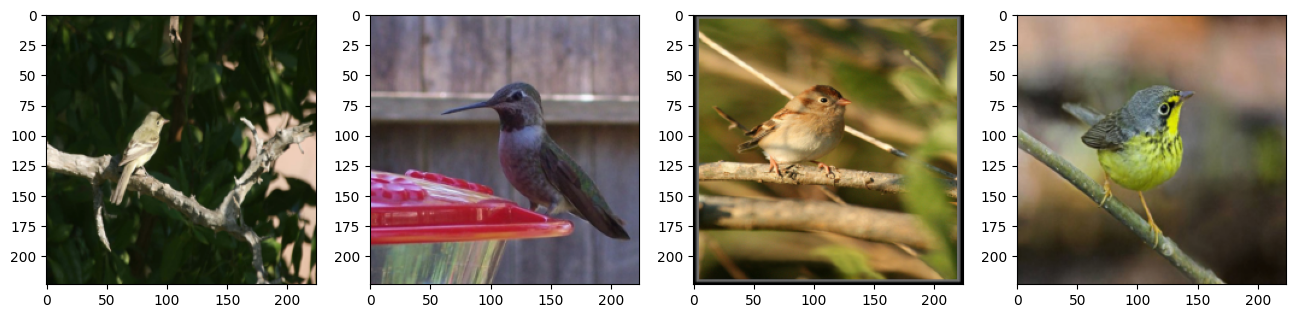

tensor([ 36,  66, 118, 161])


In [ ]:
# Plot the training images and labels

cub_denormalize = transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
to_pil_image = transforms.functional.to_pil_image

images, labels = next(iter(cub_train_loader))

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(to_pil_image(cub_denormalize(images[0])))
ax[1].imshow(to_pil_image(cub_denormalize(images[1])))
ax[2].imshow(to_pil_image(cub_denormalize(images[2])))
ax[3].imshow(to_pil_image(cub_denormalize(images[3])))
plt.show()

print(labels[:4])

# 3. Define the Model Architecture

Here we define the model. Below is very simple model with CNN. You can customize your own model and note that you are not limited to use any methods. **But you are not allowed to use pretrained weight**

In [14]:
# 모델 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN(num_classes=200).to(device)

# 학습 설정
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

# 4. Train the network

In [15]:
# 학습 루프
batch_size=64

num_epochs = 7
best_loss = float('inf')
checkpoint_dir = "/content/drive/MyDrive/AI인턴십/model/"

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(cub_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(cub_train_loader)
    epoch_acc = 100 * correct / total

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

    # 최적 모델 저장
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch + 1
        best_model_path = os.path.join(checkpoint_dir, f"trained_best_{best_epoch}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
        }, best_model_path)
        print(f"New best model saved at epoch {best_epoch} with loss: {best_loss:.4f}")

print('Finished Training')

  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [1/7], Loss: 5.3073, Acc: 0.38%
New best model saved at epoch 1 with loss: 5.3073


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [2/7], Loss: 5.2990, Acc: 0.45%
New best model saved at epoch 2 with loss: 5.2990


  0%|          | 0/94 [00:00<?, ?it/s]

...

Epoch [5/7], Loss: 5.2991, Acc: 0.48%


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [6/7], Loss: 5.2990, Acc: 0.45%
New best model saved at epoch 6 with loss: 5.2990


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [7/7], Loss: 5.2990, Acc: 0.35%
New best model saved at epoch 7 with loss: 5.2990
Finished Training


### SimpleCNN 모델을 예로 들어 프리징을 적용

In [17]:
# 모델 정의 !!!!!!!!!!!!! 구려!!!!!!!!!!!!!
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=200):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 56 * 56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.max_pool2d(x, 2)
        x = nn.functional.relu(self.conv2(x))
        x = nn.functional.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# 모델 초기화
model = SimpleCNN(num_classes=200).to(device)

# **모델의 모든 가중치를 고정(Freeze)**
for param in model.parameters():
    param.requires_grad = False

# **마지막 레이어(fc2)만 학습 가능하도록 설정**
for param in model.fc2.parameters():
    param.requires_grad = True  # fc2 레이어의 모든 파라미터에 대해 requires_grad를 True로 설정

# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.fc2.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

# 학습 루프
batch_size = 64
num_epochs = 7
best_loss = float('inf')
checkpoint_dir = "/content/drive/MyDrive/AI인턴십/model/"

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(cub_train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()  # 오류가 발생하는 부분
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(cub_train_loader)
    epoch_acc = 100 * correct / total

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

    # 최적 모델 저장
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch + 1
        best_model_path = os.path.join(checkpoint_dir, f"trained_freezing_{best_epoch}.pth")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': best_loss,
        }, best_model_path)
        print(f"New best model saved at epoch {best_epoch} with loss: {best_loss:.4f}")

print('Finished Training')


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [1/7], Loss: 5.3015, Acc: 0.50%
New best model saved at epoch 1 with loss: 5.3015


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [2/7], Loss: 5.3015, Acc: 0.50%
New best model saved at epoch 2 with loss: 5.3015


  0%|          | 0/94 [00:00<?, ?it/s]

...

Epoch [5/7], Loss: 5.3011, Acc: 0.50%
New best model saved at epoch 5 with loss: 5.3011


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [6/7], Loss: 5.3010, Acc: 0.50%
New best model saved at epoch 6 with loss: 5.3010


  0%|          | 0/94 [00:00<?, ?it/s]

Epoch [7/7], Loss: 5.3009, Acc: 0.50%
New best model saved at epoch 7 with loss: 5.3009
Finished Training


# 5. Evaluate the network on the validation data

In [20]:
import torch

# 모델 초기화
model = SimpleCNN(num_classes=200).to(device)

# 저장된 Fine-tuning 불러오기
checkpoint_path = "/content/drive/MyDrive/AI인턴십/model/trained_best_7.pth"
checkpoint = torch.load(checkpoint_path)
model.load_state_dict(checkpoint['model_state_dict'])

# 모델 검증
model.eval()  # 모델을 평가 모드로 전환
correct = 0
total = 0

with torch.no_grad():
    for data in cub_val_loader:
        images, labels = data
        outputs = model(images.to(device))
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted.cpu() == labels).sum().item()

print(f'Accuracy of the network on the 2897 validation images: {100 * correct / total:.2f} %')


<ipython-input-20-2c83b7ca7ca4>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Accuracy of the network on the 2897 validation images: 0.48 %


1. Pre-training 데이터셋과 Fine-tuning 데이터셋의 차이
CIFAR-10/100과 CUB-200-2011은 시각적으로 매우 다른 데이터셋입니다. CIFAR 데이터셋은 일반적인 객체(예: 자동차, 동물)로 구성되어 있으며, 이미지 해상도도 낮습니다.
반면, CUB-200-2011은 새의 다양한 종을 포함하며, 매우 미세한 시각적 차이가 있는 고해상도 이미지로 구성되어 있습니다.
Pre-training 모델이 CIFAR 데이터셋에서 학습한 특징들이 CUB-200-2011 데이터셋에서는 효과적이지 않을 수 있습니다.


# 6. Test and Submit

You can modify your TestDataset, but you should be mindful to align it with the training dataset and its transformations.

In [ ]:
####이건 수정안했음!! 해야됨 맞나
class TestDataset(Dataset):
    def __init__(self, img_file, transform=None):
        self.img =np.load(img_file)
        self.transform = transform

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        image = self.img[idx]
        if self.transform is not None:
            image = self.transform(image)

        return image

test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

test_dataset = TestDataset(img_file="./CUB_test_images.npy",transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

## **Do not modify the cell below!!!!**


In [ ]:
def test(model, test_loader):
  model.eval()
  test_predictions = []

  with torch.inference_mode():
      for i, data in enumerate(tqdm(test_loader)):
          data = data.float().to(device)
          output = model(data)
          test_predictions.append(output.cpu())

  return torch.cat(test_predictions, dim=0)

In [ ]:
# Save test output npy file
predictions = test(model, test_loader)
np.save('./TEAM_NAME_RESULT', predictions.numpy())

  0%|          | 0/23 [00:00<?, ?it/s]